128x128 final

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchaudio
import torchvision
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

Using device: cuda
GPU: NVIDIA GeForce RTX 3090
VRAM: 24.0 GB


In [2]:
class VGGSoundDataset(Dataset):
    def __init__(self, csv_path, target_sr=48000, target_length=480000):
        self.df = pd.read_csv(csv_path)
        self.target_sr = target_sr
        self.target_length = target_length
        
        self.image_transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
        
        print(f'Total entries in CSV: {len(self.df)}')
        
        valid_indices = []
        missing_audio = []
        missing_image = []
        missing_both = []
        
        for idx in range(len(self.df)):
            row = self.df.iloc[idx]
            audio_path = Path(row['base_folder']) / 'audio' / row['audio_file']
            image_path = Path(row['base_folder']) / 'image' / row['image_file']
            
            audio_exists = audio_path.exists()
            image_exists = image_path.exists()
            
            if audio_exists and image_exists:
                valid_indices.append(idx)
            else:
                if not audio_exists and not image_exists:
                    missing_both.append((str(audio_path), str(image_path)))
                elif not audio_exists:
                    missing_audio.append(str(audio_path))
                else:
                    missing_image.append(str(image_path))
        
        print(f'\nValidation Results:')
        print(f'  Valid pairs found: {len(valid_indices)}')
        print(f'  Missing audio only: {len(missing_audio)}')
        print(f'  Missing image only: {len(missing_image)}')
        print(f'  Missing both: {len(missing_both)}')
        print(f'  Total missing: {len(missing_audio) + len(missing_image) + len(missing_both)}')
        
        if missing_audio:
            print(f'\nFirst 5 missing audio files:')
            for path in missing_audio[:5]:
                print(f'  - {path}')
        
        if missing_image:
            print(f'\nFirst 5 missing image files:')
            for path in missing_image[:5]:
                print(f'  - {path}')
        
        if missing_both:
            print(f'\nFirst 5 missing pairs:')
            for audio, image in missing_both[:5]:
                print(f'  Audio: {audio}')
                print(f'  Image: {image}')
        
        self.df = self.df.iloc[valid_indices].reset_index(drop=True)
        
        folder_counts = self.df['base_folder'].value_counts()
        print(f'\nData distribution by folder:')
        for folder, count in folder_counts.items():
            print(f'  {folder}: {count} pairs')
        
        if 'caption' in self.df.columns:
            caption_counts = self.df['caption'].value_counts()
            print(f'\nUnique bird species: {len(caption_counts)}')
            print(f'Top 5 most common:')
            for caption, count in caption_counts.head(5).items():
                print(f'  {caption}: {count} samples')
        
        success_rate = (len(valid_indices) / len(self.df)) * 100 if len(self.df) > 0 else 0
        print(f'\nData loading success rate: {success_rate:.1f}%')
        
        if success_rate < 100:
            print(f'WARNING: Not all data was loaded. Check file paths.')
        else:
            print(f'SUCCESS: All {len(valid_indices)} entries from CSV were loaded!')
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        audio_path = Path(row['base_folder']) / 'audio' / row['audio_file']
        image_path = Path(row['base_folder']) / 'image' / row['image_file']
        
        waveform, sr = torchaudio.load(audio_path)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        if sr != self.target_sr:
            resampler = torchaudio.transforms.Resample(sr, self.target_sr)
            waveform = resampler(waveform)
        
        if waveform.shape[1] < self.target_length:
            waveform = F.pad(waveform, (0, self.target_length - waveform.shape[1]))
        else:
            waveform = waveform[:, :self.target_length]
        
        image = Image.open(image_path).convert('RGB')
        image = self.image_transform(image)
        
        return waveform.squeeze(0), image

print('Loading bird sounds dataset...')
dataset = VGGSoundDataset('bird_sounds_filtered.csv')

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(
    dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print(f'\nDataLoader Summary:')
print(f'  Train samples: {len(train_dataset)}')
print(f'  Validation samples: {len(val_dataset)}')
print(f'  Train batches: {len(train_loader)}')
print(f'  Validation batches: {len(val_loader)}')
print(f'  Batch size: 16')

print('\nTesting first batch load...')
try:
    test_audio, test_image = next(iter(train_loader))
    print(f'  Audio shape: {test_audio.shape}')
    print(f'  Image shape: {test_image.shape}')
    print('  First batch loaded successfully!')
except Exception as e:
    print(f'  ERROR loading first batch: {e}')

print('\nDataset ready for training!')

Loading bird sounds dataset...
Total entries in CSV: 832

Validation Results:
  Valid pairs found: 832
  Missing audio only: 0
  Missing image only: 0
  Missing both: 0
  Total missing: 0

Data distribution by folder:
  vggsound_02: 341 pairs
  vggsound_00: 340 pairs
  vggsound_04: 151 pairs

Unique bird species: 14
Top 5 most common:
  chicken crowing: 117 samples
  pigeon, dove cooing: 103 samples
  singing bowl: 92 samples
  bird chirping, tweeting: 85 samples
  pheasant crowing: 73 samples

Data loading success rate: 100.0%
SUCCESS: All 832 entries from CSV were loaded!

DataLoader Summary:
  Train samples: 748
  Validation samples: 84
  Train batches: 47
  Validation batches: 6
  Batch size: 16

Testing first batch load...
  Audio shape: torch.Size([16, 480000])
  Image shape: torch.Size([16, 3, 128, 128])
  First batch loaded successfully!

Dataset ready for training!


In [3]:
from transformers import ClapModel, ClapProcessor

class CLAPAudioEncoder(nn.Module):
    def __init__(self, model_name='laion/clap-htsat-fused'):
        super().__init__()
        self.model = ClapModel.from_pretrained(model_name)
        self.processor = ClapProcessor.from_pretrained(model_name)
        
        for param in self.model.parameters():
            param.requires_grad = False
    
    def forward(self, audio, sample_rate=48000):
        with torch.no_grad():
            inputs = self.processor(
                audios=audio.cpu().numpy(),
                sampling_rate=sample_rate,
                return_tensors="pt"
            )
            inputs = {k: v.to(audio.device) for k, v in inputs.items()}
            audio_embed = self.model.get_audio_features(**inputs)
        return audio_embed

class AudioProjectionMLP(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=1024, output_dim=2048, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.LayerNorm(output_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(output_dim, output_dim),
            nn.LayerNorm(output_dim)
        )
    
    def forward(self, x):
        return self.net(x)

class SelfAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.query = nn.Conv2d(channels, channels // 8, 1)
        self.key = nn.Conv2d(channels, channels // 8, 1)
        self.value = nn.Conv2d(channels, channels, 1)
        self.gamma = nn.Parameter(torch.zeros(1))
    
    def forward(self, x):
        B, C, H, W = x.shape
        query = self.query(x).view(B, -1, H * W).permute(0, 2, 1)
        key = self.key(x).view(B, -1, H * W)
        attention = F.softmax(torch.bmm(query, key), dim=-1)
        value = self.value(x).view(B, -1, H * W)
        out = torch.bmm(value, attention.permute(0, 2, 1))
        out = out.view(B, C, H, W)
        return self.gamma * out + x
    
class EMA:
    """Exponential Moving Average for smoother generator weights"""
    def __init__(self, model, decay=0.999):
        self.model = model
        self.decay = decay
        self.shadow = {}
        self.backup = {}
        
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()
    
    def update(self):
        """Update EMA weights after each generator training step"""
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.shadow[name].mul_(self.decay).add_(param.data, alpha=1 - self.decay)
    
    def apply_shadow(self):
        """Temporarily replace model weights with EMA weights"""
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.clone()
                param.data.copy_(self.shadow[name])
    
    def restore(self):
        """Restore original model weights"""
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                param.data.copy_(self.backup[name])
        self.backup = {}

class ImprovedGenerator(nn.Module):
    def __init__(self, noise_dim=128, audio_dim=2048):
        super().__init__()
        self.noise_dim = noise_dim
        self.audio_dim = audio_dim
        input_dim = noise_dim + audio_dim
        
        self.fc = nn.Linear(input_dim, 4 * 4 * 1024)
        
        self.block1 = nn.Sequential(
            nn.ConvTranspose2d(1024, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(True)
        )
        
        self.block2 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True)
        )
        
        self.attention = SelfAttention(256)
        
        self.block3 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True)
        )
        
        self.block4 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True)
        )
        
        self.block5 = nn.Sequential(
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )
        
        self.skip1 = nn.Conv2d(512, 256, 1)
        self.skip2 = nn.Conv2d(256, 128, 1)
    
    def forward(self, noise, audio_features):
        x = torch.cat([noise, audio_features], dim=1)
        x = self.fc(x)
        x = x.view(-1, 1024, 4, 4)
        
        x1 = self.block1(x)
        
        x2 = self.block2(x1)
        skip1_out = F.interpolate(self.skip1(x1), size=x2.shape[-2:], mode='nearest')
        x2 = x2 + skip1_out
        
        x2 = self.attention(x2)
        
        x3 = self.block3(x2)
        skip2_out = F.interpolate(self.skip2(x2), size=x3.shape[-2:], mode='nearest')
        x3 = x3 + skip2_out
        
        x4 = self.block4(x3)
        x5 = self.block5(x4)
        return x5

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1)),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.utils.spectral_norm(nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.utils.spectral_norm(nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.utils.spectral_norm(nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1)),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.utils.spectral_norm(nn.Conv2d(512, 1, kernel_size=8, stride=1, padding=0))
        )
    
    def forward(self, x):
        return self.model(x).view(-1)

class ImageEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1)
        self.model = nn.Sequential(*list(resnet.children())[:-1])
        
        for param in self.model.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        with torch.no_grad():
            features = self.model(x)
            return features.view(features.size(0), -1)

class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
        self.features1 = nn.Sequential(*list(vgg.features)[:4])   # relu1_2
        self.features2 = nn.Sequential(*list(vgg.features)[:9])   # relu2_2
        self.features3 = nn.Sequential(*list(vgg.features)[:16])  # relu3_3
        
        for param in self.parameters():
            param.requires_grad = False
    
    def forward(self, x, y):
        with torch.no_grad():
            x1, x2, x3 = self.features1(x), self.features2(x), self.features3(x)
            y1, y2, y3 = self.features1(y), self.features2(y), self.features3(y)
        
        loss = 2.0 * F.mse_loss(x1, y1) + 1.0 * F.mse_loss(x2, y2) + 0.5 * F.mse_loss(x3, y3)
        return loss / 3.5

print('Improved model architectures defined')

Improved model architectures defined


In [4]:
def contrastive_loss(audio_features, image_features, temperature=0.07):
    audio_features = F.normalize(audio_features, dim=1)
    image_features = F.normalize(image_features, dim=1)
    
    logits = torch.matmul(audio_features, image_features.T) / temperature
    labels = torch.arange(logits.size(0), device=logits.device)
    
    loss_audio = F.cross_entropy(logits, labels)
    loss_image = F.cross_entropy(logits.T, labels)
    
    return (loss_audio + loss_image) / 2

def adversarial_loss(pred, target):
    return F.binary_cross_entropy_with_logits(pred, target)

def r1_penalty(real_pred, real_img):
    grad_real = torch.autograd.grad(
        outputs=real_pred.sum(), 
        inputs=real_img, 
        create_graph=True
    )[0]
    grad_penalty = grad_real.pow(2).reshape(grad_real.shape[0], -1).sum(1).mean()
    return grad_penalty

def get_loss_weights(epoch):
    if epoch < 10:
        return {'contrastive': 3.0, 'adversarial': 0.5, 'mse': 1.5, 'perceptual': 0.3, 'tv': 0.001}
    elif epoch < 25:
        return {'contrastive': 2.0, 'adversarial': 1.5, 'mse': 1.0, 'perceptual': 0.3, 'tv': 0.001}
    elif epoch < 150:
        return {'contrastive': 1.0, 'adversarial': 2.5, 'mse': 1.0, 'perceptual': 0.2, 'tv': 0.002}
    else:  # Epochs 150-300
        return {'contrastive': 0.8, 'adversarial': 2.8, 'mse': 1.0, 'perceptual': 0.15, 'tv': 0.002}

def total_variation_loss(img):
    """Penalizes rapid pixel changes, reducing noise"""
    tv_h = torch.mean(torch.abs(img[:, :, 1:, :] - img[:, :, :-1, :]))
    tv_w = torch.mean(torch.abs(img[:, :, :, 1:] - img[:, :, :, :-1]))
    return tv_h + tv_w

print('Loss functions defined')

Loss functions defined


In [5]:
noise_dim = 128
num_epochs = 300        # Increase for EMA convergence
lr_mlp = 3e-4
lr_g = 8e-5             # Slightly lower for stability with EMA
lr_d = 1e-4

clap_encoder = CLAPAudioEncoder().to(device)
audio_mlp = AudioProjectionMLP().to(device)
generator = ImprovedGenerator(noise_dim=noise_dim, audio_dim=2048).to(device)
ema_generator = EMA(generator, decay=0.999)
discriminator = Discriminator().to(device)
image_encoder = ImageEncoder().to(device)
perceptual_loss_fn = PerceptualLoss().to(device)

clap_encoder.eval()
image_encoder.eval()
perceptual_loss_fn.eval()

optimizer_mlp = torch.optim.AdamW(audio_mlp.parameters(), lr=lr_mlp, betas=(0.5, 0.999), weight_decay=0.02)
optimizer_g = torch.optim.AdamW(generator.parameters(), lr=lr_g, betas=(0.5, 0.999), weight_decay=0.02)
optimizer_d = torch.optim.AdamW(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999), weight_decay=0.02)

scheduler_mlp = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_mlp, T_max=num_epochs)
scheduler_g = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_g, T_max=num_epochs)
scheduler_d = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_d, T_max=num_epochs)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Audio MLP parameters: {count_parameters(audio_mlp):,}')
print(f'Generator parameters: {count_parameters(generator):,}')
print(f'Discriminator parameters: {count_parameters(discriminator):,}')
print(f'Total trainable parameters: {count_parameters(audio_mlp) + count_parameters(generator) + count_parameters(discriminator):,}')

fixed_audio_samples = []
for i, (audio, _) in enumerate(train_loader):
    if i == 0:
        fixed_audio_samples = audio[:4].to(device)
        break

print(f'Fixed audio samples for tracking: {fixed_audio_samples.shape}')
print('Initialization complete')

Audio MLP parameters: 6,831,104
Generator parameters: 47,061,508
Discriminator parameters: 2,789,313
Total trainable parameters: 56,681,925
Fixed audio samples for tracking: torch.Size([4, 480000])
Initialization complete


In [ ]:
def denormalize(tensor):
    return (tensor * 0.5 + 0.5).clamp(0, 1)

def save_checkpoint(epoch, audio_mlp, generator, ema_generator, path='checkpoints_birdv7'):
    Path(path).mkdir(exist_ok=True)
    checkpoint = {
        'epoch': epoch,
        'audio_mlp_state_dict': audio_mlp.state_dict(),
        'generator_state_dict': generator.state_dict(),
        'ema_shadow': ema_generator.shadow,  # Save EMA weights
        'noise_dim': noise_dim
    }
    torch.save(checkpoint, f'{path}/checkpoint_epoch_{epoch}.pt')
    print(f'Checkpoint saved at epoch {epoch}')

def generate_samples(audio_mlp, generator, ema_generator, fixed_audio, epoch):
    audio_mlp.eval()
    generator.eval()
    
    # Use EMA weights for better quality samples
    ema_generator.apply_shadow()

    with torch.no_grad():
        audio_features = clap_encoder(fixed_audio, sample_rate=48000)
        audio_features = audio_mlp(audio_features)
        noise = torch.randn(len(fixed_audio), noise_dim, device=device)
        fake_images = generator(noise, audio_features)
        fake_images = denormalize(fake_images)

    # Restore training weights
    ema_generator.restore()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i in range(4):
        img = fake_images[i].cpu().permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f'Sample {i+1}')
    plt.suptitle(f'Epoch {epoch}')
    plt.tight_layout()
    plt.show()

    audio_mlp.train()
    generator.train()

history = {
    'train_loss_d': [], 'train_loss_g': [], 'train_loss_contrastive': [],
    'train_loss_mse': [], 'train_loss_perceptual': [], 'train_loss_tv': []
}

print('Starting training...')

for epoch in range(1, num_epochs + 1):
    audio_mlp.train()
    generator.train()
    discriminator.train()
    
    loss_weights = get_loss_weights(epoch)
    
    epoch_loss_d = 0.0
    epoch_loss_g = 0.0
    epoch_loss_contrastive = 0.0
    epoch_loss_mse = 0.0
    epoch_loss_perceptual = 0.0
    d_train_count = 0
    epoch_loss_tv = 0.0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs}')
    
    last_loss_d = 0.0
    
    for batch_idx, (audio, real_images) in enumerate(pbar):
        batch_size = audio.size(0)
        audio = audio.to(device)
        real_images = real_images.to(device)
        
        audio_features_clap = clap_encoder(audio, sample_rate=48000)
        audio_features = audio_mlp(audio_features_clap)
        
        image_features = image_encoder(real_images)
        loss_contrastive = contrastive_loss(audio_features, image_features)
        
        noise = torch.randn(batch_size, noise_dim, device=device)
        fake_images = generator(noise, audio_features.detach())
        
        real_labels = torch.full((batch_size,), 0.9, device=device)
        fake_labels = torch.full((batch_size,), 0.1, device=device)
        
        if batch_idx % 2 == 0:
            optimizer_d.zero_grad()
            
            noise_std = 0.05 * max(0, 1.0 - epoch / num_epochs)
            real_images_noisy = real_images + noise_std * torch.randn_like(real_images)
            fake_images_noisy = fake_images.detach() + noise_std * torch.randn_like(fake_images)
            
            real_images_noisy.requires_grad = True
            real_output = discriminator(real_images_noisy)
            fake_output = discriminator(fake_images_noisy)
            
            loss_d_real = adversarial_loss(real_output, real_labels)
            loss_d_fake = adversarial_loss(fake_output, fake_labels)
            
            r1_loss = r1_penalty(real_output, real_images_noisy)
            
            loss_d = (loss_d_real + loss_d_fake) / 2 + 5.0 * r1_loss
            
            loss_d.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
            optimizer_d.step()
            
            epoch_loss_d += loss_d.item()
            d_train_count += 1
            last_loss_d = loss_d.item()
        
        optimizer_mlp.zero_grad()
        optimizer_g.zero_grad()
        
        fake_images = generator(noise, audio_features)
        fake_output = discriminator(fake_images)
        loss_g_adv = adversarial_loss(fake_output, real_labels)
        loss_mse = F.mse_loss(fake_images, real_images)
        loss_perceptual = perceptual_loss_fn(fake_images, real_images)
        
        loss_tv = total_variation_loss(fake_images)

        loss_g = (loss_weights['adversarial'] * loss_g_adv +
                loss_weights['mse'] * loss_mse +
                loss_weights['perceptual'] * loss_perceptual +
                loss_weights['contrastive'] * loss_contrastive +
                loss_weights['tv'] * loss_tv)
        
        loss_g.backward()
        torch.nn.utils.clip_grad_norm_(audio_mlp.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
        optimizer_mlp.step()
        optimizer_g.step()
        ema_generator.update()
        
        epoch_loss_g += loss_g.item()
        epoch_loss_contrastive += loss_contrastive.item()
        epoch_loss_mse += loss_mse.item()
        epoch_loss_perceptual += loss_perceptual.item()
        epoch_loss_tv += loss_tv.item()
        
        if (batch_idx + 1) % 50 == 0:
            pbar.set_postfix({
                'D': f'{last_loss_d:.3f}',
                'G': f'{loss_g.item():.3f}',
                'Cont': f'{loss_contrastive.item():.3f}'
            })
    
    scheduler_mlp.step()
    scheduler_g.step()
    scheduler_d.step()
    
    avg_loss_d = epoch_loss_d / max(1, d_train_count)
    avg_loss_g = epoch_loss_g / len(train_loader)
    avg_loss_contrastive = epoch_loss_contrastive / len(train_loader)
    avg_loss_mse = epoch_loss_mse / len(train_loader)
    avg_loss_perceptual = epoch_loss_perceptual / len(train_loader)
    avg_loss_tv = epoch_loss_tv / len(train_loader)

    history['train_loss_tv'].append(avg_loss_tv)
    history['train_loss_d'].append(avg_loss_d)
    history['train_loss_g'].append(avg_loss_g)
    history['train_loss_contrastive'].append(avg_loss_contrastive)
    history['train_loss_mse'].append(avg_loss_mse)
    history['train_loss_perceptual'].append(avg_loss_perceptual)
    
    print(f'Epoch {epoch} Summary:')
    print(f'  D Loss: {avg_loss_d:.4f} (trained on {d_train_count}/{len(train_loader)} batches)')
    print(f'  G Loss: {avg_loss_g:.4f}')
    print(f'  Contrastive Loss: {avg_loss_contrastive:.4f}')
    print(f'  MSE Loss: {avg_loss_mse:.4f}')
    print(f'  Perceptual Loss: {avg_loss_perceptual:.4f}')
    print(f'  TV Loss: {avg_loss_tv:.4f}')
    
    if epoch % 10 == 0:  # Changed from always to every 10
        generate_samples(audio_mlp, generator, ema_generator, fixed_audio_samples, epoch)

    if epoch % 10 == 0:  # Changed from every 5 to every 10
        save_checkpoint(epoch, audio_mlp, generator, ema_generator)

print('Training complete')

In [7]:
def load_model_for_inference(checkpoint_path, device='cuda'):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    clap_encoder = CLAPAudioEncoder().to(device)
    audio_mlp = AudioProjectionMLP().to(device)
    generator = ImprovedGenerator(noise_dim=checkpoint['noise_dim'], audio_dim=2048).to(device)

    audio_mlp.load_state_dict(checkpoint['audio_mlp_state_dict'])
    generator.load_state_dict(checkpoint['generator_state_dict'])
    
    # Load and apply EMA weights for inference
    ema_generator = EMA(generator, decay=0.999)
    ema_generator.shadow = checkpoint['ema_shadow']
    ema_generator.apply_shadow()

    clap_encoder.eval()
    audio_mlp.eval()
    generator.eval()

    print(f'Model loaded from {checkpoint_path}')
    print(f'Epoch: {checkpoint["epoch"]}')
    print(f'Using EMA weights for inference')

    return clap_encoder, audio_mlp, generator

def generate_image_from_audio(audio_path, clap_encoder, audio_mlp, generator, device='cuda', num_samples=1):
    waveform, sr = torchaudio.load(audio_path)
    
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != 48000:
        resampler = torchaudio.transforms.Resample(sr, 48000)
        waveform = resampler(waveform)
    
    target_length = 480000
    if waveform.shape[1] < target_length:
        waveform = F.pad(waveform, (0, target_length - waveform.shape[1]))
    else:
        waveform = waveform[:, :target_length]
    
    waveform = waveform.squeeze(0).to(device)
    
    with torch.no_grad():
        audio_features = clap_encoder(waveform.unsqueeze(0), sample_rate=48000)
        audio_features = audio_mlp(audio_features)
        
        noise = torch.randn(num_samples, generator.noise_dim, device=device)
        
        audio_features_expanded = audio_features.repeat(num_samples, 1)
        fake_images = generator(noise, audio_features_expanded)
        fake_images = (fake_images * 0.5 + 0.5).clamp(0, 1)
    
    if num_samples == 1:
        img = fake_images[0].cpu().permute(1, 2, 0).numpy()
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title('Generated Image')
        plt.show()
        return img
    else:
        fig, axes = plt.subplots(1, num_samples, figsize=(4*num_samples, 4))
        images = []
        for i in range(num_samples):
            img = fake_images[i].cpu().permute(1, 2, 0).numpy()
            images.append(img)
            if num_samples > 1:
                axes[i].imshow(img)
                axes[i].axis('off')
                axes[i].set_title(f'Sample {i+1}')
            else:
                axes.imshow(img)
                axes.axis('off')
                axes.set_title(f'Sample {i+1}')
        plt.tight_layout()
        plt.show()
        return images

print('Inference functions defined')
print('Usage:')
print('  clap_enc, mlp, gen = load_model_for_inference("checkpoints_birdv7/checkpoint_epoch_300.pt")')
print('  generate_image_from_audio("path/to/audio.wav", clap_enc, mlp, gen, num_samples=4)')

Inference functions defined
Usage:
  clap_enc, mlp, gen = load_model_for_inference("checkpoints_birdv7/checkpoint_epoch_300.pt")
  generate_image_from_audio("path/to/audio.wav", clap_enc, mlp, gen, num_samples=4)


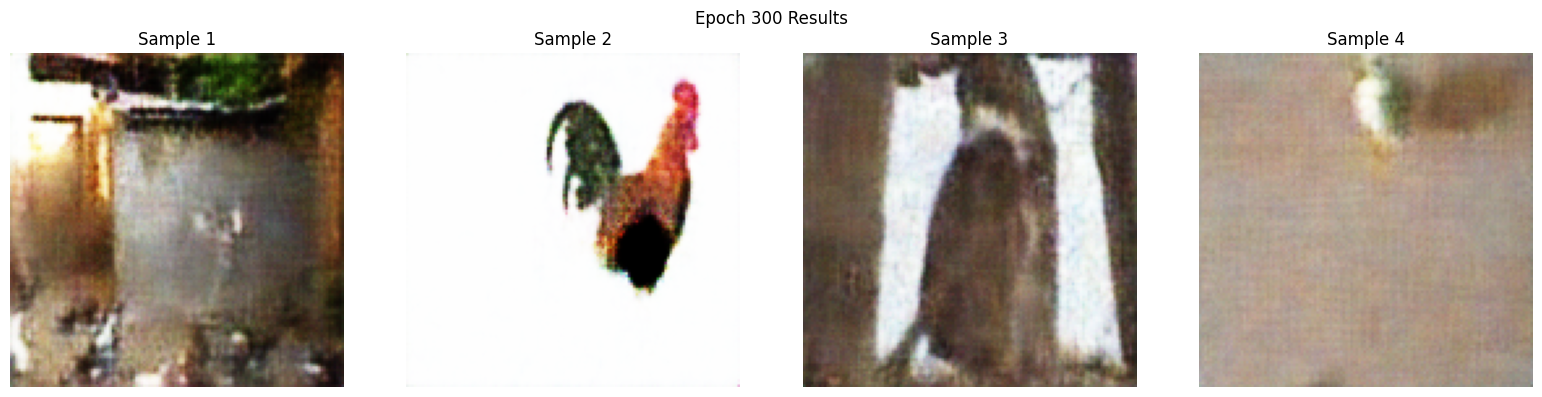

In [8]:
# Load specific checkpoint and display
checkpoint_epoch = 300  # Change this to any saved epoch
checkpoint = torch.load(f'checkpoints_birdv7/checkpoint_epoch_{checkpoint_epoch}.pt', map_location=device)

audio_mlp.load_state_dict(checkpoint['audio_mlp_state_dict'])
generator.load_state_dict(checkpoint['generator_state_dict'])

audio_mlp.eval()
generator.eval()

with torch.no_grad():
    audio_features = clap_encoder(fixed_audio_samples, sample_rate=48000)
    audio_features = audio_mlp(audio_features)
    noise = torch.randn(len(fixed_audio_samples), noise_dim, device=device)
    fake_images = generator(noise, audio_features)
    fake_images = (fake_images * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    img = fake_images[i].cpu().permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'Sample {i+1}')
plt.suptitle(f'Epoch {checkpoint_epoch} Results')
plt.tight_layout()
plt.show()

Epoch 300 Summary:
  D Loss: 0.6930
  G Loss: 2.1650
  Contrastive Loss: 0.0060
  MSE Loss: 0.0182
  Perceptual Loss: 1.3352


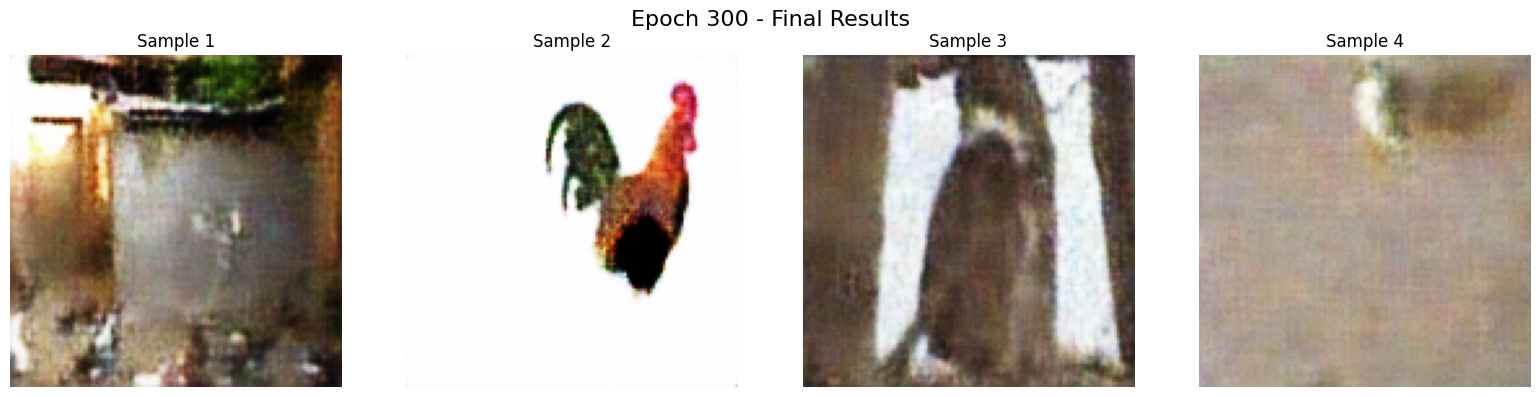

ImprovedGenerator(
  (fc): Linear(in_features=2176, out_features=16384, bias=True)
  (block1): Sequential(
    (0): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (block2): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (attention): SelfAttention(
    (query): Conv2d(256, 32, kernel_size=(1, 1), stride=(1, 1))
    (key): Conv2d(256, 32, kernel_size=(1, 1), stride=(1, 1))
    (value): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
  )
  (block3): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)

In [9]:
# Display Epoch 300 Results

# Get loss metrics from history
epoch_idx = 299  

print("=" * 60)
print(f"Epoch 300 Summary:")
print("=" * 60)
print(f"  D Loss: {history['train_loss_d'][epoch_idx]:.4f}")
print(f"  G Loss: {history['train_loss_g'][epoch_idx]:.4f}")
print(f"  Contrastive Loss: {history['train_loss_contrastive'][epoch_idx]:.4f}")
print(f"  MSE Loss: {history['train_loss_mse'][epoch_idx]:.4f}")
print(f"  Perceptual Loss: {history['train_loss_perceptual'][epoch_idx]:.4f}")
print("=" * 60)

# Generate and display images
audio_mlp.eval()
generator.eval()

with torch.no_grad():
    audio_features = clap_encoder(fixed_audio_samples, sample_rate=48000)
    audio_features = audio_mlp(audio_features)
    noise = torch.randn(len(fixed_audio_samples), noise_dim, device=device)
    fake_images = generator(noise, audio_features)
    fake_images = (fake_images * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    img = fake_images[i].cpu().permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'Sample {i+1}')
plt.suptitle('Epoch 300 - Final Results', fontsize=16)
plt.tight_layout()
plt.show()

audio_mlp.train()
generator.train()

version 7 training

| Epoch | D Loss | G Loss  | Contrastive Loss | MSE Loss | Perceptual Loss |
|-------|--------|---------|------------------|----------|-----------------|
| 1     | 0.6799 | 8.7744  | 2.2861           | 0.3722   | 3.2007          |
| 50    | 0.6933 | 2.2705  | 0.0295           | 0.0780   | 2.1496          |
| 100   | 0.6930 | 2.1369  | 0.0123           | 0.0404   | 1.7569          |
| 150   | 0.6930 | 2.2132  | 0.0088           | 0.0280   | 1.5709          |
| 200   | 0.6930 | 2.1826  | 0.0066           | 0.0216   | 1.4174          |
| 300   | 0.6930 | 2.1650  | 0.0060           | 0.0182   | 1.3352          |

Image not found: training/v7epoch1.png


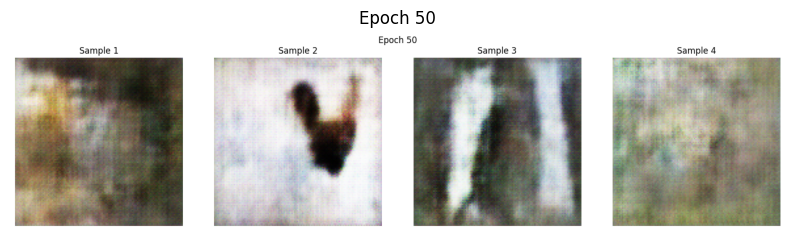

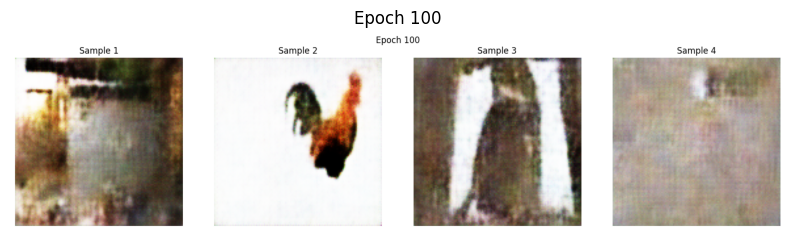

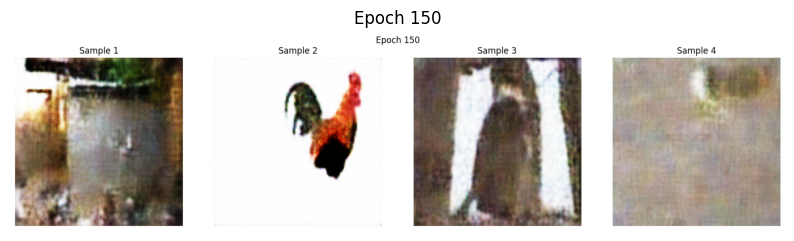

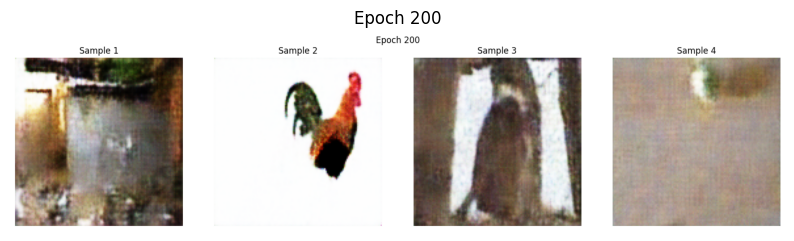

Image not found: training/v7epoch250.png


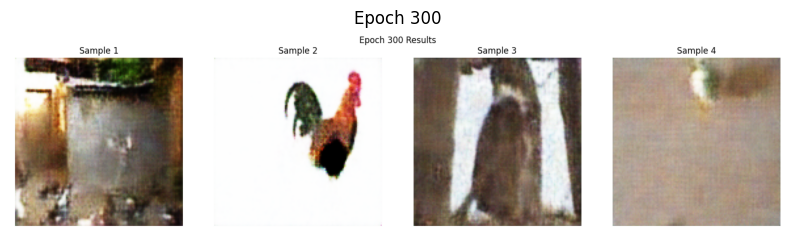

In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import os

base_path = "training/v7epoch{}.png"

epochs = [1] + list(range(50, 301, 50))  

for epoch in epochs:
    img_path = base_path.format(epoch)
    
    if os.path.exists(img_path):
        img = Image.open(img_path)
        
        plt.figure(figsize=(10, 10))
        plt.imshow(img)
        plt.title(f'Epoch {epoch}')
        plt.axis('off')
        plt.show()
    else:
        print(f"Image not found: {img_path}")